In [1]:
import PriceRatioExperiment as PRE

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import random

In [2]:
N = 100
num = 11

prod_values = np.logspace(-1, 1, num)
labor_coeffs = 1.0/prod_values

In [3]:
T = 500

n = len(labor_coeffs)
n = n*n

l_ratio_df = []
p_ratio_df = []
p_ratio_std_df = []
c1_df = []

for l1 in labor_coeffs:
    
    print(l1)
    
    for l2 in labor_coeffs:
        
        try:
    
            c1 = np.random.uniform(0, 1.0/l1)
            c2 = 1.0/l2*(1.0 - l1*c1)

            pre = PRE.PriceRatioExperiment(N, l1, l2, c1, c2)
            print(l1, l2)
            print(c1, c2)
            print(pre.N1, pre.N2)
            print(l1*c1 + l2*c2)
            print()

            Me_df, Qe_df, ntries_df, p_df = pre.run_experiment(T)

            p_ratio     = np.nanmean(p_df[:,0]/p_df[:,1])
            p_ratio_std = np.nanstd(p_df[:,0]/p_df[:,1])

            
        except:
            
            print('Fail for')
            print(l1, l2)
            print()
            
            p_ratio = np.nan
            p_ratio_std = np.nan
        
        l_ratio_df.append(l1/l2)
        p_ratio_df.append(p_ratio)
        p_ratio_std_df.append(p_ratio_std)
        c1_df.append(c1)

        
        
        

10.0
10.0 10.0
0.0866376932640507 0.013362306735949304
87 13
1.0



C:\Users\Alex\Documents\Research\EconoABM\EconoNet\2024-01-28_Testing_Price_Ratios\PriceRatioExperiment.py:96: RuntimeWarning: invalid value encountered in divide
  self.p_df = self.Me_df/self.Qe_df


10.0 6.3095734448019325
0.04346327478055587 0.08960467092434155
43 57
1.0

10.0 3.9810717055349727
0.04618165189754027 0.13518557836482797
46 54
1.0

10.0 2.5118864315095797
0.03858906511198376 0.24448133529313196
39 61
1.0

10.0 1.5848931924611132
0.0658156632233302 0.2156885835542419
66 34
1.0

10.0 1.0
0.014702711841608741 0.8529728815839126
15 85
1.0

10.0 0.630957344480193
0.08493818598093408 0.23871366504932953
85 15
1.0

10.0 0.3981071705534971
0.0824359981475151 0.4411877793626597
82 18
1.0

10.0 0.25118864315095796
0.001202286948348108 3.9332078000149466
1 99
0.9999999999999999

10.0 0.15848931924611132
0.049344400304956626 3.196152266663626
49 51
1.0

10.0 0.1
0.09766391454782666 0.2336085452173342
98 2
1.0

6.3095734448019325
6.3095734448019325 10.0
0.11068379963837287 0.030163243703194488
70 30
1.0

6.3095734448019325 6.3095734448019325
0.13651163130809257 0.021977687938018776
86 14
1.0

6.3095734448019325 3.9810717055349727
0.08996174728235513 0.10860888230124628
57 43
1.0

C:\Users\Alex\AppData\Local\Temp\ipykernel_2672\86730695.py:31: RuntimeWarning: Mean of empty slice
  p_ratio     = np.nanmean(p_df[:,0]/p_df[:,1])
C:\Users\Alex\anaconda3\envs\pytorchgame3.10\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


1.5848931924611132 1.5848931924611132
0.07121856502328501 0.5597387794569083
11 89
0.9999999999999999

1.5848931924611132 1.0
0.09834338281731671 0.8441362420492375
16 84
1.0

1.5848931924611132 0.630957344480193
0.05338545970261384 1.4507949805942169
8 92
1.0

1.5848931924611132 0.3981071705534971
0.4375251215518993 0.7700675496385649
69 31
1.0

1.5848931924611132 0.25118864315095796
0.18591583075779294 2.8080221168173125
29 71
1.0

1.5848931924611132 0.15848931924611132
0.5840863946389994 0.4687094984119402
93 7
1.0

1.5848931924611132 0.1
0.36390457897677153 4.232501100742873
58 42
1.0

1.0
1.0 10.0
0.5145910076455814 0.04854089923544186
51 49
1.0

1.0 6.3095734448019325
0.02336595453855772 0.15478606501775974
2 98
0.9999999999999999

1.0 3.9810717055349727
0.05025363732829813 0.23856550017706246
5 95
1.0

1.0 2.5118864315095797
0.7102835348289165 0.11533820221202092
71 29
1.0

1.0 1.5848931924611132
0.8939593959707303 0.06690709792538373
89 11
1.0

1.0 1.0
0.5927781496430353 0.4072

(0.005, 200.0)

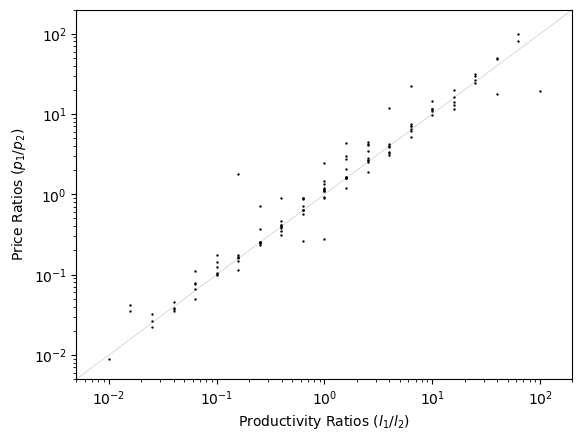

In [13]:
plt.scatter(l_ratio_df, p_ratio_df, s = 0.5, c='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Productivity Ratios ($l_1/l_2$)')
plt.ylabel('Price Ratios ($p_1/p_2$)')

x = np.logspace(-3,3,10)
plt.plot(x,x, c='k', lw=0.1)
plt.xlim(5e-3, 2e2)
plt.ylim(5e-3, 2e2)

Text(0, 0.5, 'Price Ratio Standard Deviations')

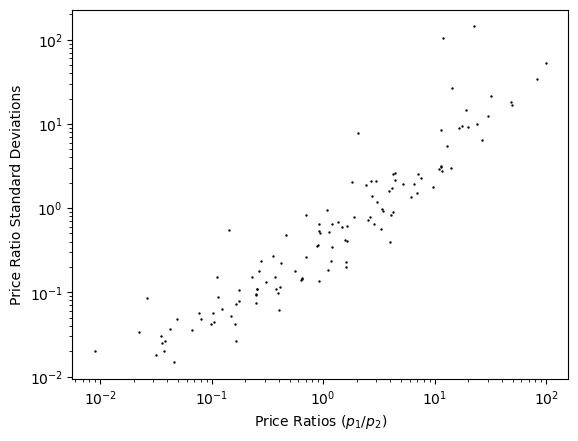

In [5]:
plt.scatter(p_ratio_df, p_ratio_std_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel('Price Ratio Standard Deviations')

Text(0, 0.5, '$\\bar{c}_1$')

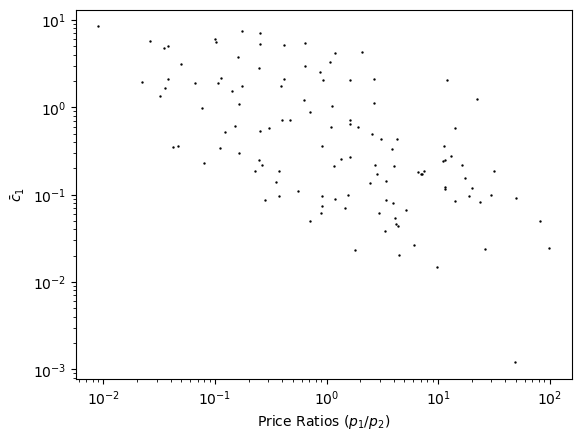

In [6]:
plt.scatter(p_ratio_df, c1_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel(r'$\bar{c}_1$')